## Delievery dataset

Target feature : `Time_taken(min)`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('./data/train.csv')

In [3]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,8:30:00,8:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,5/4/2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [4]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

In [5]:
df.shape

(45593, 20)

In [6]:
df.dtypes

ID                              object
Delivery_person_ID              object
Delivery_person_Age             object
Delivery_person_Ratings         object
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weatherconditions               object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries             object
Festival                        object
City                            object
Time_taken(min)                 object
dtype: object

In [7]:
df.isna().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [8]:
df.isna().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

- There are null in the data but the above shows 0. this is because the NaN has uneven spacing.
- To resolve this i am using regular expression.
- It will replace all the variants of nan such as `Nan`, `_Nan`, `NaN_`, `_NaN_`

In [9]:
df = df.replace(r'^\s*NaN\s*$', np.nan, regex=True)

nan_summary = df.isna().sum()

print("Missing values after cleaning:\n")
print(nan_summary[nan_summary > 0])


Missing values after cleaning:

Delivery_person_Age        1854
Delivery_person_Ratings    1908
Time_Orderd                1731
Road_traffic_density        601
multiple_deliveries         993
Festival                    228
City                       1200
dtype: int64


In [10]:
df.nunique()

ID                             45593
Delivery_person_ID              1320
Delivery_person_Age               22
Delivery_person_Ratings           28
Restaurant_latitude              657
Restaurant_longitude             518
Delivery_location_latitude      4373
Delivery_location_longitude     4373
Order_Date                        44
Time_Orderd                      176
Time_Order_picked                193
Weatherconditions                  7
Road_traffic_density               4
Vehicle_condition                  4
Type_of_order                      4
Type_of_vehicle                    4
multiple_deliveries                4
Festival                           2
City                               3
Time_taken(min)                   45
dtype: int64

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Restaurant_latitude,45593.0,17.017729,8.185109,-30.905562,12.933284,18.546947,22.728163,30.914057
Restaurant_longitude,45593.0,70.231332,22.883647,-88.366217,73.170000,75.898497,78.044095,88.433452
Delivery_location_latitude,45593.0,17.465186,7.335122,0.010000,12.988453,18.633934,22.785049,31.054057
Delivery_location_longitude,45593.0,70.845702,21.118812,0.010000,73.280000,76.002574,78.107044,88.563452
Vehicle_condition,45593.0,1.023359,0.839065,0.000000,0.000000,1.000000,2.000000,3.000000


- Removing `(min)` from target feature.

In [12]:
df["Time_taken(min)"] = df["Time_taken(min)"].str.replace("(min)", "", regex=False).str.strip().astype(int)
df["Time_taken(min)"].head()

0    24
1    33
2    26
3    21
4    30
Name: Time_taken(min), dtype: int64

---

# Feature Descriptions

### Identifiers
- **ID**: Unique identifier for each order/delivery.  
- **Delivery_person_ID**: Unique identifier of the delivery person.  

### Delivery Person Attributes
- **Delivery_person_Age**: Age of the delivery person.  
- **Delivery_person_Ratings**: Ratings given to delivery person by customers (scale 1–5).  
- **Vehicle_condition**: Condition of the delivery vehicle (0 = poor, higher = better).  
- **multiple_deliveries**: Number of deliveries handled by delivery person in one trip.  

### Location Details
- **Restaurant_latitude**: Latitude of the restaurant.  
- **Restaurant_longitude**: Longitude of the restaurant.  
- **Delivery_location_latitude**: Latitude of the customer’s delivery location.  
- **Delivery_location_longitude**: Longitude of the customer’s delivery location.  

### Date & Time
- **Order_Date**: Date of the order.  
- **Time_Orderd**: Time when the order was placed.  
- **Time_Order_picked**: Time when the order was picked up by the delivery person.  

### External Conditions
- **Weatherconditions**: Weather at the time of delivery (e.g., Sunny, Rainy, Stormy).  
- **Road_traffic_density**: Traffic conditions (e.g., Low, Medium, High, Jam).  
- **Festival**: Whether the order was placed during a festival period (Yes/No).  
- **City**: City where the delivery took place.  

### Order & Vehicle
- **Type_of_order**: Type of order (e.g., Snack, Meal, Drinks).  
- **Type_of_vehicle**: Vehicle used for delivery (e.g., Bike, Scooter, Car).  

### Target Variable
- **Time_taken(min)**: Actual delivery time in minutes (our target variable).  
--- 

#### 1. Histplot to understand the target variable

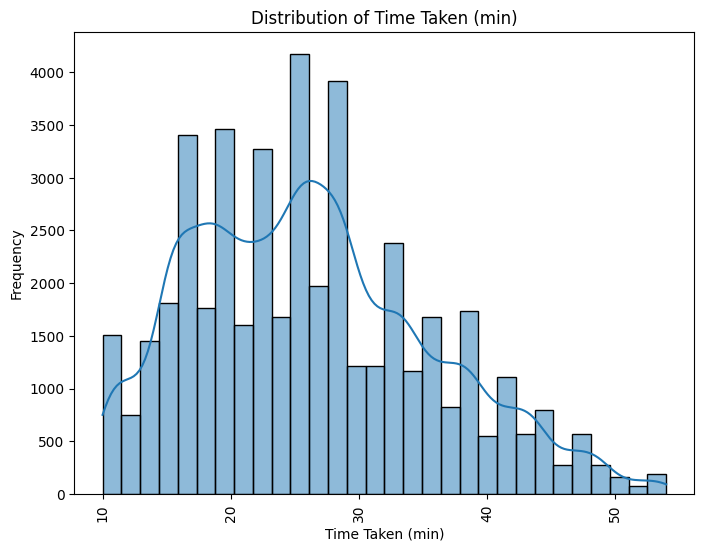

In [13]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Time_taken(min)'], bins=30, kde=True)
plt.title('Distribution of Time Taken (min)')
plt.xlabel('Time Taken (min)')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.show()

#### 2. outliers detection of target feature 

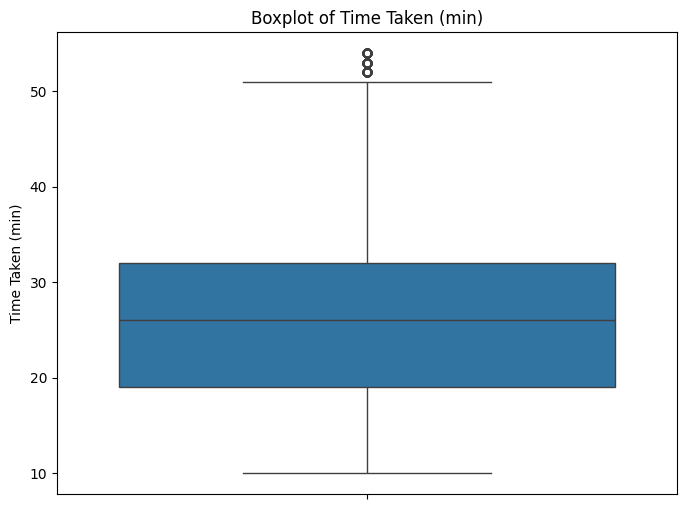

In [14]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Time_taken(min)'])
plt.title('Boxplot of Time Taken (min)')
plt.ylabel('Time Taken (min)')
plt.show()

-> Data perfectly balanced as the median is true centre

#### 3. Delivery person age relation

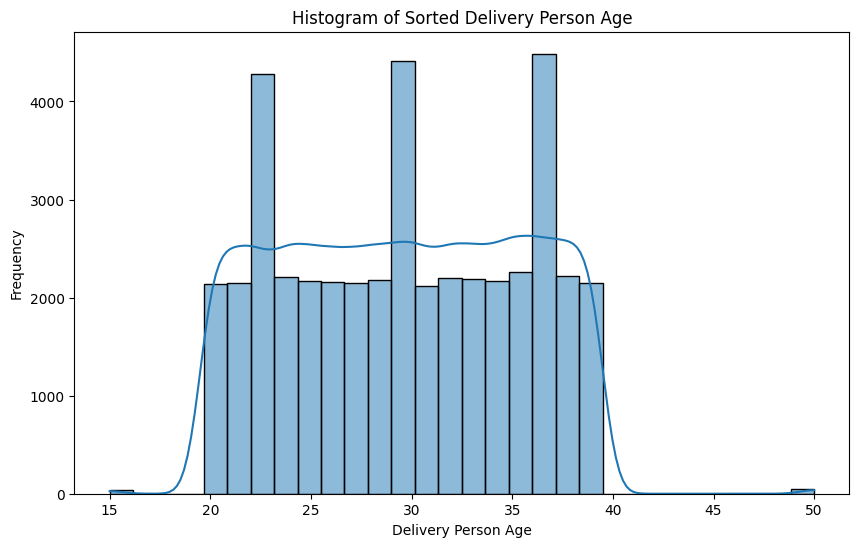

In [15]:
sorted_ages = df['Delivery_person_Age'].dropna().astype(int).sort_values()
plt.figure(figsize=(10, 6))
sns.histplot(sorted_ages, bins=30, kde=True)
plt.title('Histogram of Sorted Delivery Person Age')
plt.xlabel('Delivery Person Age')
plt.ylabel('Frequency')
plt.show()

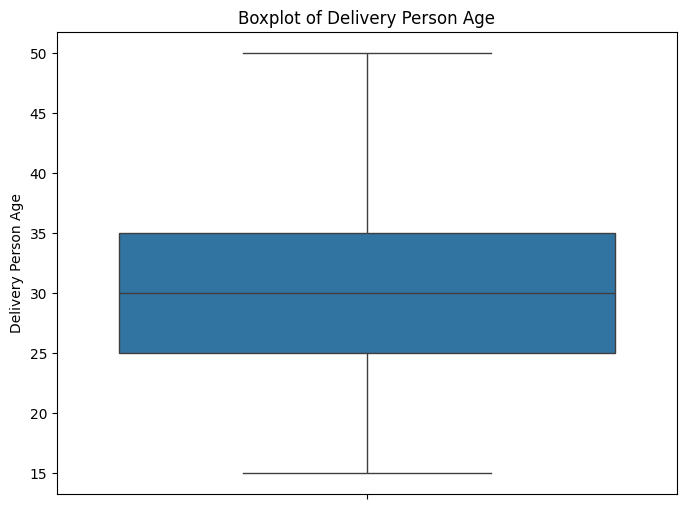

In [16]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=sorted_ages)
plt.title('Boxplot of Delivery Person Age')
plt.ylabel('Delivery Person Age')
plt.show()

4. Other categorical features 

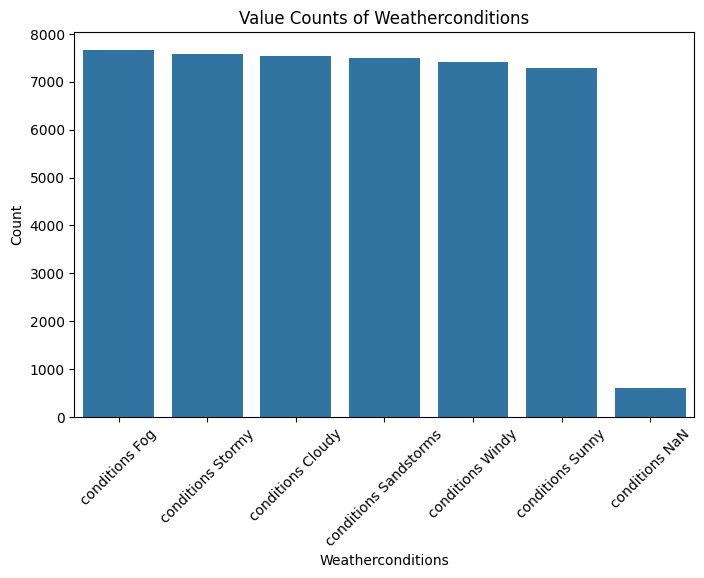

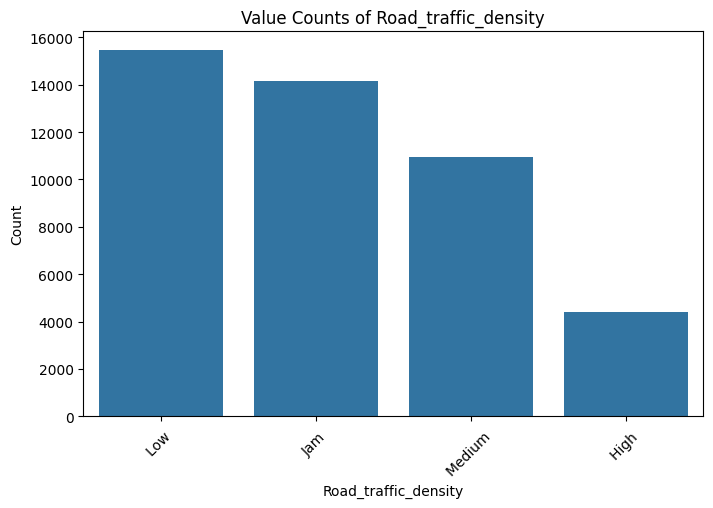

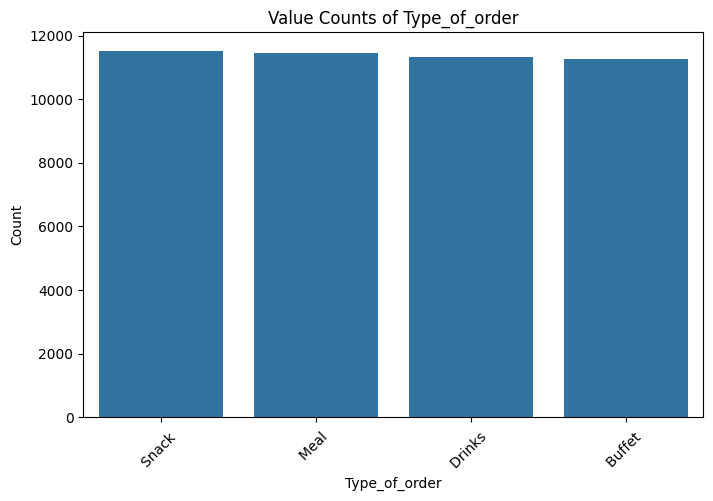

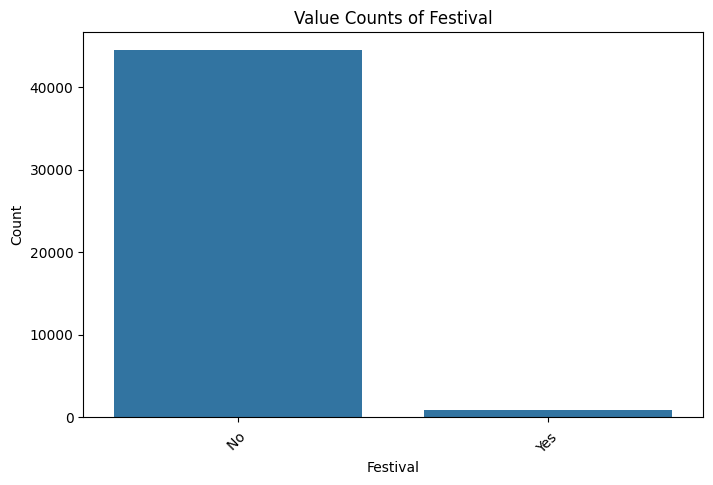

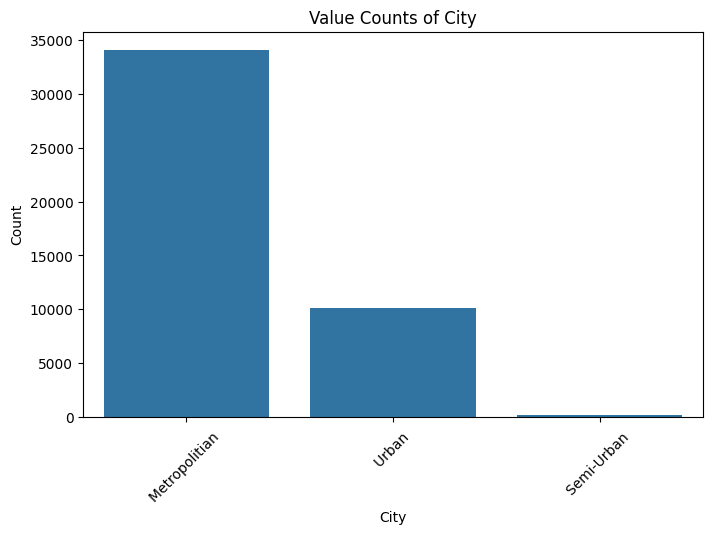

In [17]:
categorical_cols = ['Weatherconditions', 'Road_traffic_density', 'Type_of_order', 'Festival', 'City']

for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.barplot(x=df[col].value_counts().index, y=df[col].value_counts().values)
    plt.title(f'Value Counts of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

- `type_of_order` and `road_traffic_density` are balanced.

- `wheather conditions` have few nulls

- `Fesitval` is highly imbalanced but affects the predictions.

- `City` has three categories in which semi-urban are very few

#### 5. Relationship with Delivery_person_Age

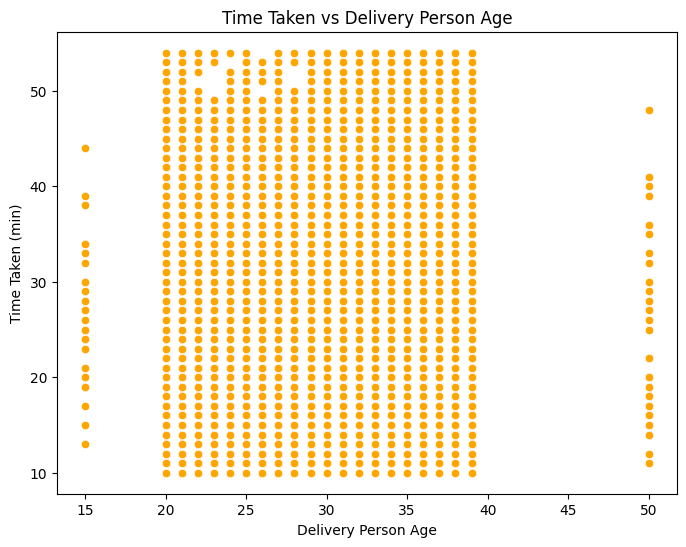

In [19]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=sorted_ages, y=df['Time_taken(min)'], color='orange')
plt.title('Time Taken vs Delivery Person Age')
plt.xlabel('Delivery Person Age')
plt.ylabel('Time Taken (min)')
plt.show()

#### 6. Relationship with Delivery_person_Ratings

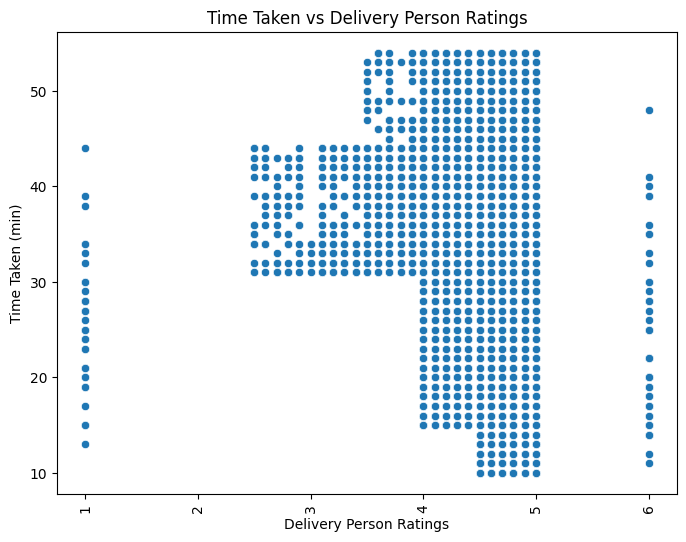

In [22]:
sorted_ratings = df['Delivery_person_Ratings'].dropna().astype(float).sort_values()
plt.figure(figsize=(8, 6))
sns.scatterplot(x=sorted_ratings, y=df['Time_taken(min)'])
plt.title('Time Taken vs Delivery Person Ratings')
plt.xlabel('Delivery Person Ratings')
plt.ylabel('Time Taken (min)')
plt.xticks(rotation=90)
plt.show()

-> ratings exceeding 5 are false values

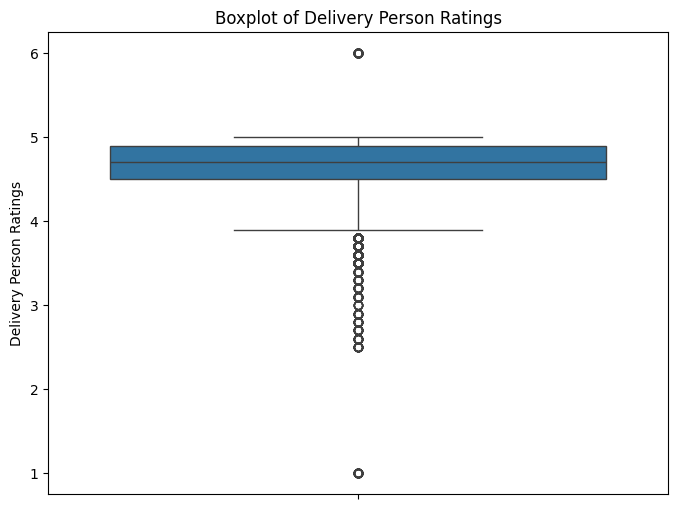

In [23]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=sorted_ratings)
plt.title('Boxplot of Delivery Person Ratings')
plt.ylabel('Delivery Person Ratings')
plt.show()

#### 7. Relationship with Vehicle_condition

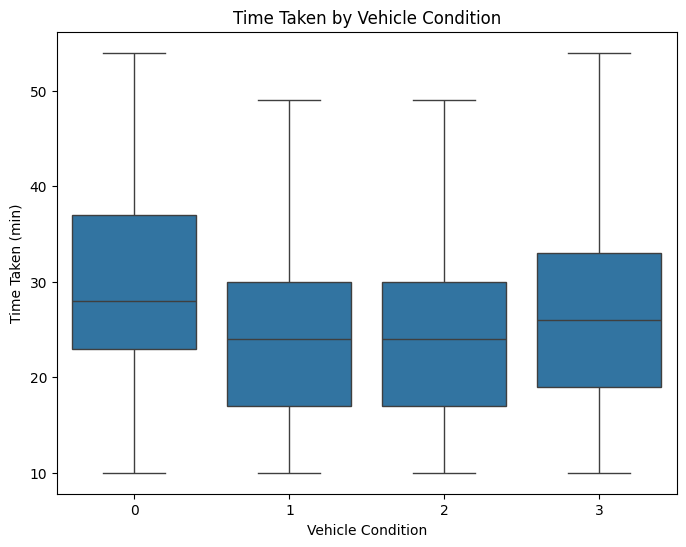

In [24]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Vehicle_condition'], y=df['Time_taken(min)'])
plt.title('Time Taken by Vehicle Condition')
plt.xlabel('Vehicle Condition')
plt.ylabel('Time Taken (min)')
plt.show()

#### 8. Relationship with multiple_deliveries

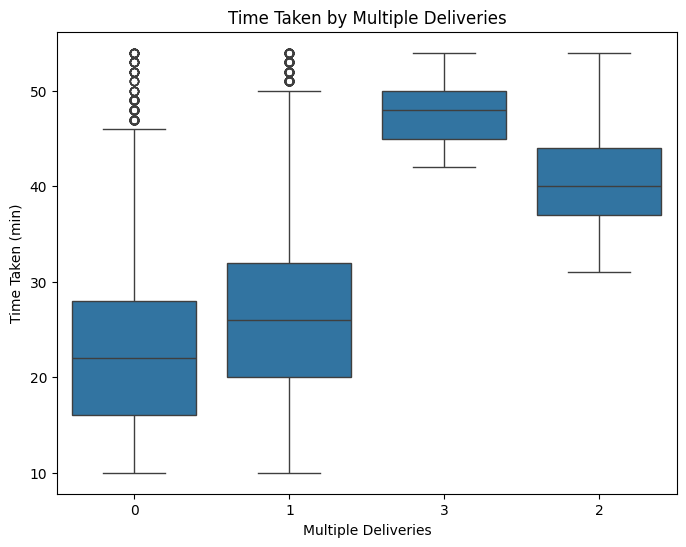

In [25]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['multiple_deliveries'], y=df['Time_taken(min)'])
plt.title('Time Taken by Multiple Deliveries')
plt.xlabel('Multiple Deliveries')
plt.ylabel('Time Taken (min)')
plt.show()

#### 9. Relationship with Road_traffic_density

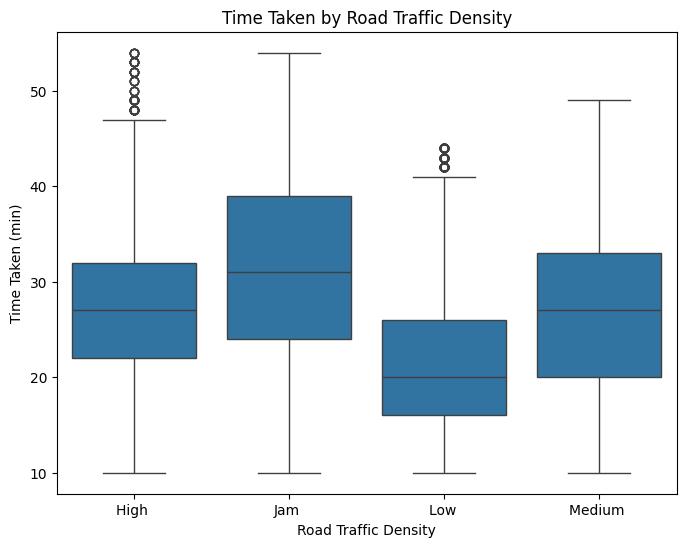

In [26]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Road_traffic_density'], y=df['Time_taken(min)'])
plt.title('Time Taken by Road Traffic Density')
plt.xlabel('Road Traffic Density')
plt.ylabel('Time Taken (min)')
plt.show()

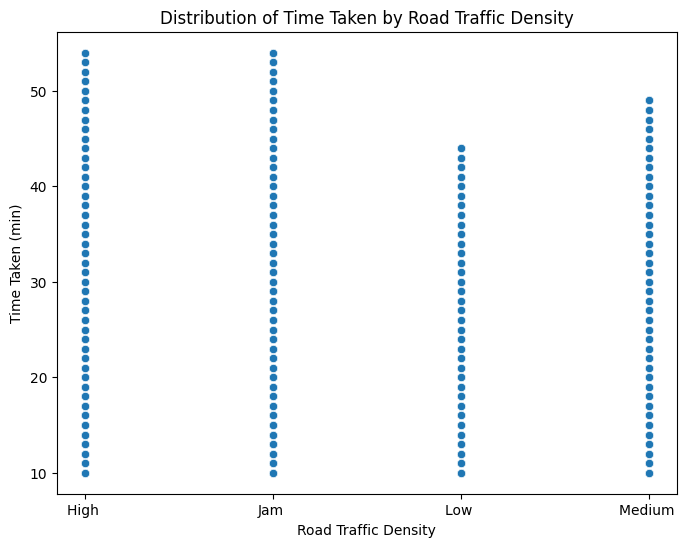

In [28]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Road_traffic_density'], y=df['Time_taken(min)'])
plt.title('Distribution of Time Taken by Road Traffic Density')
plt.xlabel('Road Traffic Density')
plt.ylabel('Time Taken (min)')
plt.show()

#### 10. Relationship with Weatherconditions

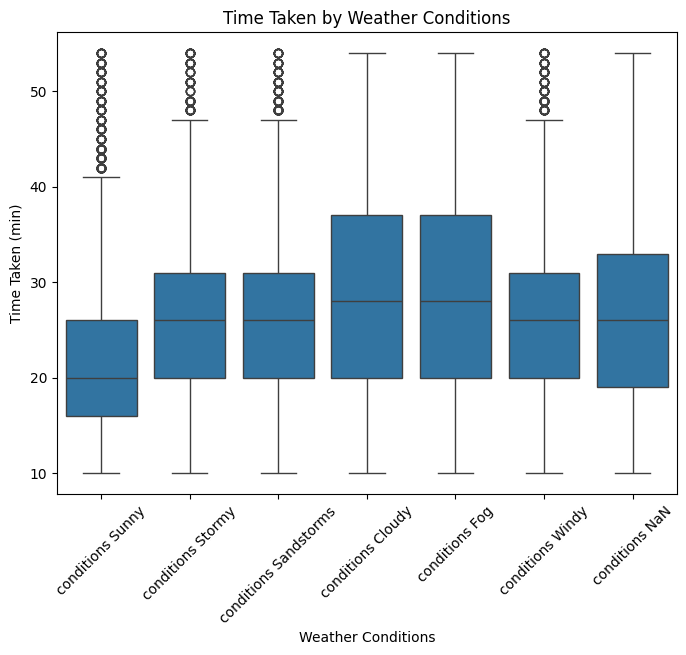

In [29]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Weatherconditions'], y=df['Time_taken(min)'])
plt.title('Time Taken by Weather Conditions')
plt.xlabel('Weather Conditions')
plt.ylabel('Time Taken (min)')
plt.xticks(rotation=45)
plt.show()

-> condition NaN can be considered as normal condition

#### 11. Compare delivery time across different Type_of_order

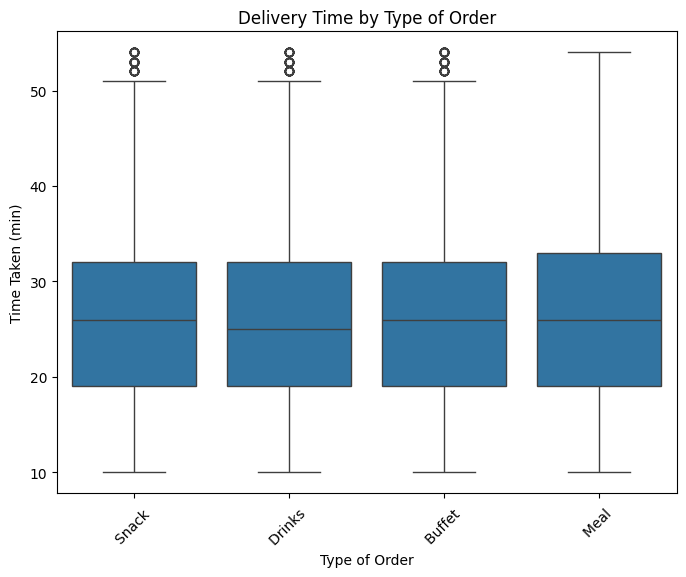

In [30]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Type_of_order'], y=df['Time_taken(min)'])
plt.title('Delivery Time by Type of Order')
plt.xlabel('Type of Order')
plt.ylabel('Time Taken (min)')
plt.xticks(rotation=45)
plt.show()

#### 12. Compare delivery time across different Type_of_vehicle

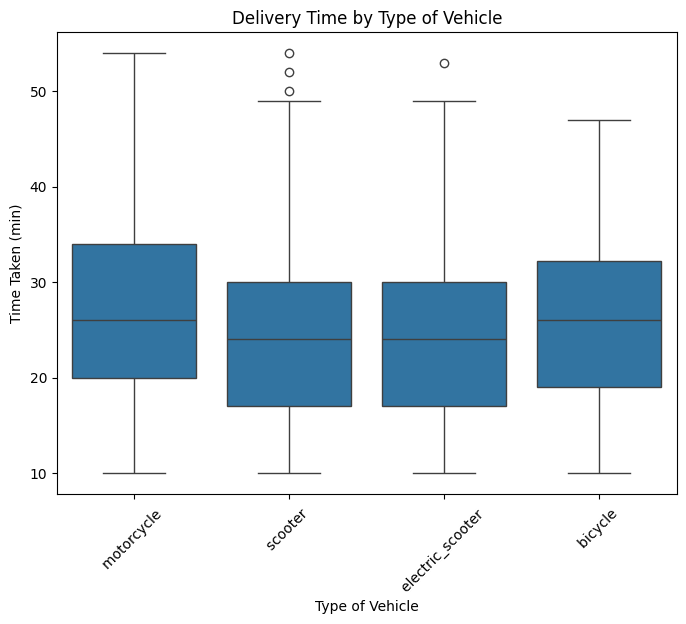

In [31]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Type_of_vehicle'], y=df['Time_taken(min)'])
plt.title('Delivery Time by Type of Vehicle')
plt.xlabel('Type of Vehicle')
plt.ylabel('Time Taken (min)')
plt.xticks(rotation=45)
plt.show()

->  very few outliers

#### 13. Checking effect of festival

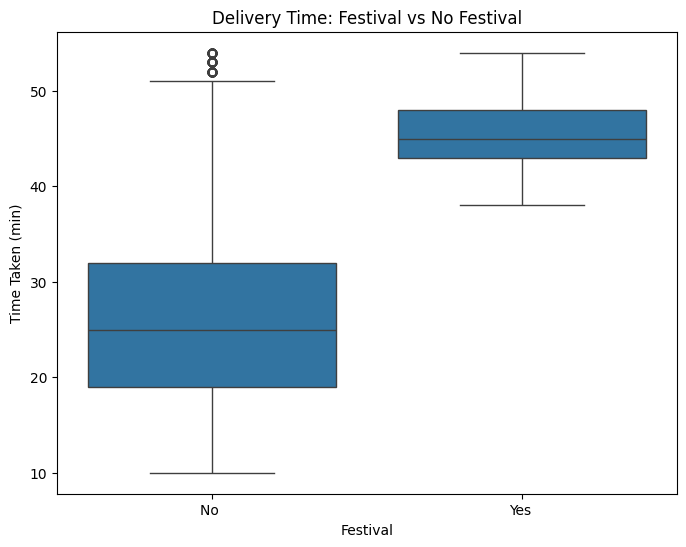

In [32]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Festival'], y=df['Time_taken(min)'])
plt.title('Delivery Time: Festival vs No Festival')
plt.xlabel('Festival')
plt.ylabel('Time Taken (min)')
plt.show()

-> it shows on festival the delivery time is more 

#### 14. City-wise delivery time distribution

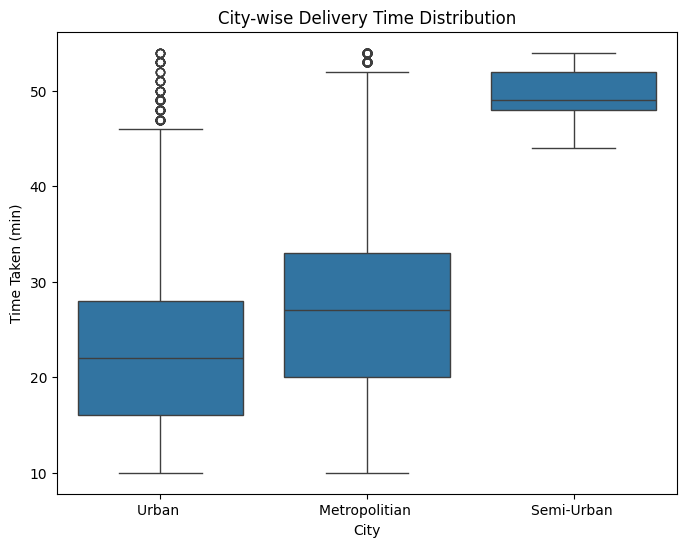

In [36]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['City'], y=df['Time_taken(min)'])
plt.title('City-wise Delivery Time Distribution')
plt.xlabel('City')
plt.ylabel('Time Taken (min)')
plt.show()

#### 15. Avg delivery time by City + Road_traffic_density

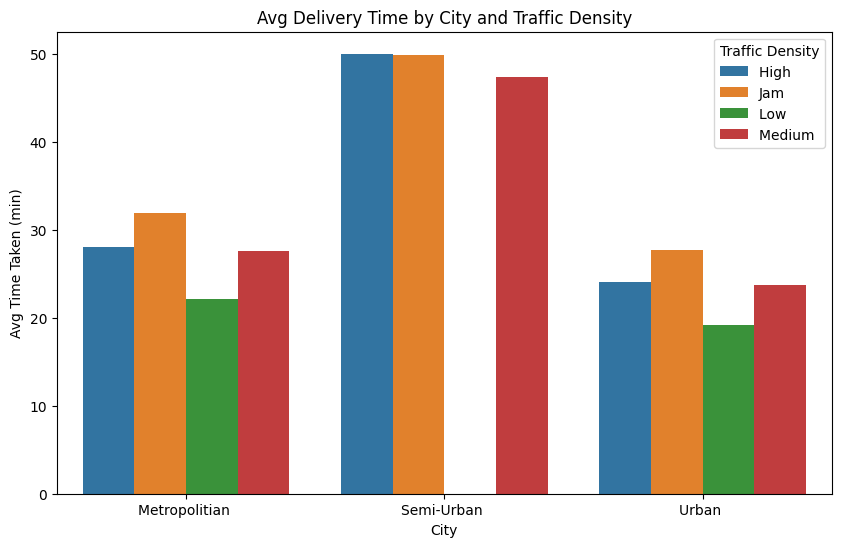

In [38]:
city_traffic = df.groupby(['City', 'Road_traffic_density'])['Time_taken(min)'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='City', y='Time_taken(min)', hue='Road_traffic_density', data=city_traffic)
plt.title('Avg Delivery Time by City and Traffic Density')
plt.ylabel('Avg Time Taken (min)')
plt.xlabel('City')
plt.legend(title='Traffic Density')
plt.show()

- Semi-urban city has more delivery time
- metropolitian and urban has almost same average of dekivery time

#### 16. Distance between restaurent and delivery location

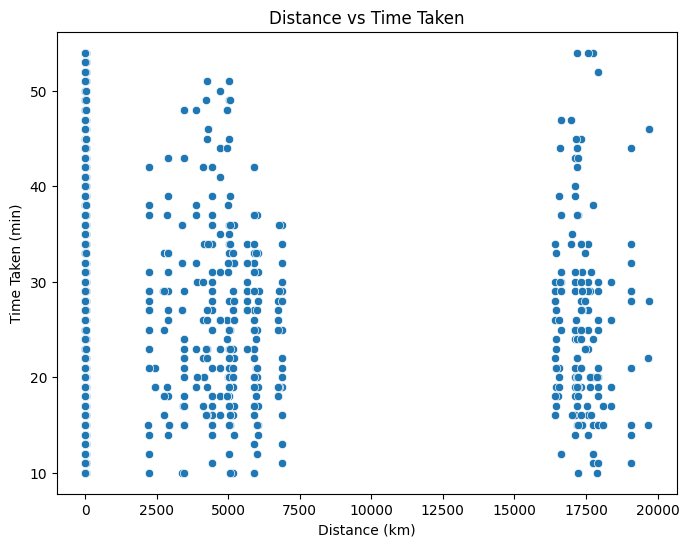

Correlation between distance and time taken: -0.00


In [37]:
from numpy import radians, sin, cos, sqrt, arctan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * arctan2(sqrt(a), sqrt(1-a))
    return R * c

df['distance_km'] = haversine(
    df['Restaurant_latitude'], df['Restaurant_longitude'],
    df['Delivery_location_latitude'], df['Delivery_location_longitude']
)

# Analyze correlation between distance and time taken
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['distance_km'], y=df['Time_taken(min)'])
plt.title('Distance vs Time Taken')
plt.xlabel('Distance (km)')
plt.ylabel('Time Taken (min)')
plt.show()

corr = df[['distance_km', 'Time_taken(min)']].corr().iloc[0,1]
print(f"Correlation between distance and time taken: {corr:.2f}")